In [1]:

# =====================================================
# 1. Imports and setup
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [2]:
# =====================================================
# 2. PredRNN Cell (ST-LSTM with Memory Decoupling)
# =====================================================
class PredRNNCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim

        self.conv_xh = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)
        self.conv_m = nn.Conv2d(hidden_dim, 3 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, h_prev, c_prev, m_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.conv_xh(combined)
        i, f, g, o = torch.chunk(gates, 4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c = f * c_prev + i * g

        m_gates = self.conv_m(m_prev)
        mi, mf, mg = torch.chunk(m_gates, 3, dim=1)
        mi = torch.sigmoid(mi)
        mf = torch.sigmoid(mf)
        mg = torch.tanh(mg)

        m = mf * m_prev + mi * mg

        h = o * torch.tanh(c + m)
        return h, c, m


In [3]:
# =====================================================
# 3. PredRNN Network
# =====================================================
class PredRNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, kernel_size, num_layers, out_steps):
        super().__init__()
        self.num_layers = num_layers
        self.out_steps = out_steps

        self.cells = nn.ModuleList([
            PredRNNCell(input_dim if i == 0 else hidden_dims[i-1], hidden_dims[i], kernel_size)
            for i in range(num_layers)
        ])

        self.conv_out = nn.Conv2d(hidden_dims[-1], input_dim, kernel_size=1)

    def forward(self, x, teacher_forcing_ratio=0.0):
        # x: [B, Tin, C, H, W]
        B, Tin, C, H, W = x.shape
        device = x.device

        h = [torch.zeros(B, cell.hidden_dim, H, W, device=device) for cell in self.cells]
        c = [torch.zeros_like(h_i) for h_i in h]
        m = [torch.zeros_like(h_i) for h_i in h]

        outputs = []
        prev = x[:, -1]

        for t in range(self.out_steps):
            inp = prev
            for l, cell in enumerate(self.cells):
                h[l], c[l], m[l] = cell(inp, h[l], c[l], m[l])
                inp = h[l]
            frame = self.conv_out(inp)
            outputs.append(frame)

            if np.random.rand() < teacher_forcing_ratio:
                prev = x[:, -1]  # ground truth (simplified)
            else:
                prev = frame.detach()

        return torch.stack(outputs, dim=1)


In [4]:
# =====================================================
# 4. Scheduled Sampling Strategy (Normal - High to Low)
# =====================================================
def scheduled_sampling(epoch, max_epochs, start_ratio=0.9, end_ratio=0.1):
    """
    Early epochs: high teacher forcing (easy mode - learn correct patterns)
    Late epochs: low teacher forcing (hard mode - learn to predict independently)
    Linearly decreases from start_ratio to end_ratio
    """
    if max_epochs == 1:
        return start_ratio
    ratio = start_ratio - (start_ratio - end_ratio) * (epoch - 1) / (max_epochs - 1)
    return max(end_ratio, ratio)

In [5]:
# =====================================================
# 5. Training Loop
# =====================================================
def train_predrnn(model, train_loader, val_loader, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        tf_ratio = scheduled_sampling(epoch, epochs, start_ratio=0.9, end_ratio=0.1)
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            preds = model(x, teacher_forcing_ratio=tf_ratio)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                preds = model(x, teacher_forcing_ratio=0.0)
                val_loss += criterion(preds, y).item()

        val_loss /= len(val_loader)

        # 🔥 SAVE BEST MODEL HERE
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_loss": val_loss
                },
                "checkpoints/predrnn_best.pt"
            )

        print(f"Epoch {epoch}/{epochs} | TF ratio: {tf_ratio:.2f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

In [11]:
import os
os.makedirs("checkpoints", exist_ok=True)


In [6]:
DATA_DIR = "data/processed"

X_train = np.load(f"{DATA_DIR}/X_train.npy",mmap_mode="r")
Y_train = np.load(f"{DATA_DIR}/Y_train.npy",mmap_mode="r")

X_val = np.load(f"{DATA_DIR}/X_val.npy",mmap_mode="r")
Y_val = np.load(f"{DATA_DIR}/Y_val.npy",mmap_mode="r")

X_test = np.load(f"{DATA_DIR}/X_test.npy",mmap_mode="r")
Y_test = np.load(f"{DATA_DIR}/Y_test.npy",mmap_mode="r")

print("Train:", X_train.shape, Y_train.shape)
print("Val:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

# Verify normalization (should be ~0 mean, ~1 std)
#print(f"\nData stats (should be ~0 mean, ~1 std if normalized):")
#print(f"X_train mean: {X_train.mean().item():.4f}, std: {X_train.std().item():.4f}")
#print(f"Y_train mean: {Y_train.mean().item():.4f}, std: {Y_train.std().item():.4f}")


Train: (1531, 12, 2, 141, 141) (1531, 6, 2, 141, 141)
Val: (499, 12, 2, 141, 141) (499, 6, 2, 141, 141)
Test: (499, 12, 2, 141, 141) (499, 6, 2, 141, 141)


In [7]:
class WeatherDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float()
        y = torch.from_numpy(self.Y[idx]).float()
        return x, y


In [8]:
from torch.utils.data import DataLoader
BATCH_SIZE = 2  # keep small for memory

train_loader = DataLoader(
    WeatherDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers=2,
    #pin_memory=True
)

val_loader = DataLoader(
    WeatherDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    #num_workers=2,
    #pin_memory=True
)

test_loader = DataLoader(
    WeatherDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    #num_workers=2,
    #pin_memory=True
)


In [9]:
#Initialize Predrnn model with increased capacity

model = PredRNN(
    input_dim=2,                  # u, v
    hidden_dims=[64, 64, 64],  # 3-layer PredRNN
    kernel_size=3,
    num_layers=3,
    out_steps=Y_train.shape[1]     # Tout
).to(DEVICE)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")


1.075138 M parameters


In [12]:
#train predrnn model with more epochs
EPOCHS = 100  
LR = 1e-3

train_predrnn(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR
)



Epoch 1/100 | TF ratio: 0.90 | Train Loss: 0.0676 | Val Loss: 0.0671
Epoch 2/100 | TF ratio: 0.89 | Train Loss: 0.0602 | Val Loss: 0.0634
Epoch 3/100 | TF ratio: 0.88 | Train Loss: 0.0577 | Val Loss: 0.0737
Epoch 4/100 | TF ratio: 0.88 | Train Loss: 0.0556 | Val Loss: 0.0694
Epoch 5/100 | TF ratio: 0.87 | Train Loss: 0.0538 | Val Loss: 0.0654
Epoch 6/100 | TF ratio: 0.86 | Train Loss: 0.0526 | Val Loss: 0.0606
Epoch 7/100 | TF ratio: 0.85 | Train Loss: 0.0516 | Val Loss: 0.0581
Epoch 8/100 | TF ratio: 0.84 | Train Loss: 0.0507 | Val Loss: 0.0596
Epoch 9/100 | TF ratio: 0.84 | Train Loss: 0.0498 | Val Loss: 0.0612
Epoch 10/100 | TF ratio: 0.83 | Train Loss: 0.0491 | Val Loss: 0.0563
Epoch 11/100 | TF ratio: 0.82 | Train Loss: 0.0485 | Val Loss: 0.0576
Epoch 12/100 | TF ratio: 0.81 | Train Loss: 0.0478 | Val Loss: 0.0591
Epoch 13/100 | TF ratio: 0.80 | Train Loss: 0.0474 | Val Loss: 0.0576
Epoch 14/100 | TF ratio: 0.79 | Train Loss: 0.0467 | Val Loss: 0.0554
Epoch 15/100 | TF ratio: 0.79

In [13]:
# Evaluate on test set
model.eval()
criterion = torch.nn.MSELoss()
test_loss = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x, teacher_forcing_ratio=0.0)
        test_loss += criterion(preds, y).item()

test_loss /= len(test_loader)
print("PredRNN Test MSE:", test_loss)

PredRNN Test MSE: 0.05067392207682133


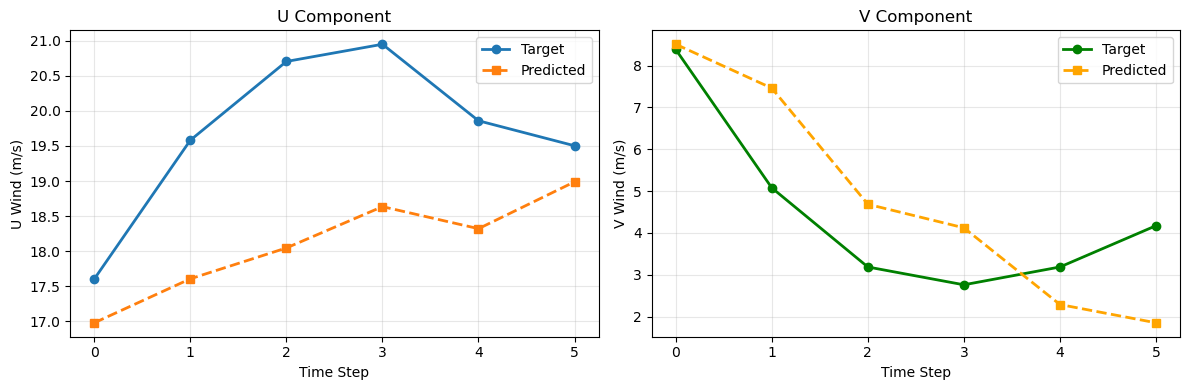

In [14]:
# Quick visualization: u and v predicted vs target
model.eval()
with torch.no_grad():
    x, y = next(iter(test_loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    preds = model(x, teacher_forcing_ratio=0.0).cpu().numpy()
    targets = y.cpu().numpy()

# Denormalize
mean = np.load("data/processed/mean.npy").reshape(1, 1, 2, 1, 1)
std = np.load("data/processed/std.npy").reshape(1, 1, 2, 1, 1)
preds = preds * std + mean
targets = targets * std + mean

# Plot u and v time series at a specific location
sample, lat_idx, lon_idx = 0, 100, 140
time_steps = range(preds.shape[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# U component
ax1.plot(time_steps, targets[sample, :, 0, lat_idx, lon_idx], 'o-', label='Target', linewidth=2)
ax1.plot(time_steps, preds[sample, :, 0, lat_idx, lon_idx], 's--', label='Predicted', linewidth=2)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('U Wind (m/s)')
ax1.set_title('U Component')
ax1.legend()
ax1.grid(True, alpha=0.3)

# V component
ax2.plot(time_steps, targets[sample, :, 1, lat_idx, lon_idx], 'o-', label='Target', linewidth=2, color='green')
ax2.plot(time_steps, preds[sample, :, 1, lat_idx, lon_idx], 's--', label='Predicted', linewidth=2, color='orange')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('V Wind (m/s)')
ax2.set_title('V Component')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
